# Import Packages

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
from torchinfo import summary
from tqdm.auto import tqdm


# Config

In [2]:
T = 1000
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1 - beta
alpha_cumprod = torch.cumprod(alpha, dim=0)
sqrt_acp = torch.sqrt(alpha_cumprod)
sqrt_omacp = torch.sqrt(1 - alpha_cumprod)

image_size = 32  # the generated image resolution
train_batch_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Dataloader

In [3]:
dataset_name = "zalando-datasets/fashion_mnist"
dataset = load_dataset(dataset_name, split="train")

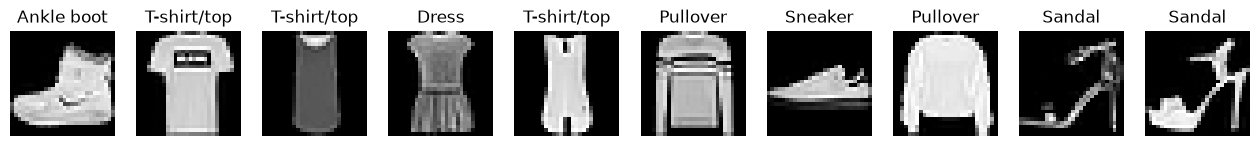

In [4]:
# Official label names mapped to their respective indices (0-9)
label_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axs = plt.subplots(1, 10, figsize=(16, 4))

for i in range(10):
    sample = dataset[i]
    image = sample["image"]
    label_idx = sample["label"]
    
    # Render image in grayscale
    axs[i].imshow(image, cmap="gray")
    axs[i].set_axis_off()
    
    # Add the text label as the title
    axs[i].set_title(label_names[label_idx], fontsize=12)

plt.show()


In [5]:
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

In [6]:
def transform(examples):
    images = [preprocess(image) for image in examples["image"]]
    return {"images": images, "labels": examples["label"]}  # adjust key name to match your dataset

dataset.set_transform(transform)

In [7]:
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

# Model

## U-Net

In [8]:
# ----------------------------
# Sinusoidal timestep embedding
# ----------------------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: [B] long/float tensor of timesteps
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)   # [B, half]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)  # [B, dim]
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


# ----------------------------
# Time-conditioned ResNet block with GroupNorm + Dropout
# ----------------------------
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, time_dim, groups=8, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, in_c), in_c)
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_c)  # FiLM-style additive conditioning

        self.norm2 = nn.GroupNorm(min(groups, out_c), out_c)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)

        self.skip = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]   # inject time info
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


# ----------------------------
# Self-attention block (used at lower resolutions only)
# ----------------------------
class AttnBlock(nn.Module):
    def __init__(self, channels, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(min(groups, channels), channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]          # each [B, C, HW]
        attn = torch.softmax((q.transpose(1, 2) @ k) / math.sqrt(C), dim=-1)  # [B,HW,HW]
        out = (v @ attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)


# ----------------------------
# Down / Up sampling with learnable parameters
# ----------------------------
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.op = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.op = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


# ----------------------------
# Full U-Net with GroupNorm, Dropout, multi-ResBlock stages,
# attention at low resolution, learnable down/up-sampling,
# and explicit timestep conditioning
# ----------------------------
class UNet2ch(nn.Module):
    def __init__(self, base_ch=64, time_dim=256, layers_per_block=2, dropout=0.1,
                num_classes=10):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(base_ch),
            nn.Linear(base_ch, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.class_emb = nn.Embedding(num_classes, time_dim)  # project class directly to time_dim, so it can be ADDED to t_emb

        self.in_conv = nn.Conv2d(1, base_ch, 3, padding=1)   # back to image-only channels, no concat

        # ---- Encoder ----
        self.enc1 = nn.ModuleList([ResBlock(base_ch, base_ch, time_dim, dropout=dropout)
                                    for _ in range(layers_per_block)])
        self.down1 = Downsample(base_ch)

        self.enc2 = nn.ModuleList([ResBlock(base_ch if i == 0 else base_ch*2, base_ch*2, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])
        self.down2 = Downsample(base_ch*2)

        self.enc3 = nn.ModuleList([ResBlock(base_ch*2 if i == 0 else base_ch*4, base_ch*4, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])
        self.attn3 = AttnBlock(base_ch*4)         # attention at the lower resolution
        self.down3 = Downsample(base_ch*4)

        # ---- Bottleneck ----
        self.bottleneck1 = ResBlock(base_ch*4, base_ch*8, time_dim, dropout=dropout)
        self.bottleneck_attn = AttnBlock(base_ch*8)
        self.bottleneck2 = ResBlock(base_ch*8, base_ch*8, time_dim, dropout=dropout)

        # ---- Decoder ----
        self.up3 = Upsample(base_ch*8)
        self.dec3 = nn.ModuleList([ResBlock(base_ch*8 + base_ch*4 if i == 0 else base_ch*4, base_ch*4, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])
        self.dec3_attn = AttnBlock(base_ch*4)

        self.up2 = Upsample(base_ch*4)
        self.dec2 = nn.ModuleList([ResBlock(base_ch*4 + base_ch*2 if i == 0 else base_ch*2, base_ch*2, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])

        self.up1 = Upsample(base_ch*2)
        self.dec1 = nn.ModuleList([ResBlock(base_ch*2 + base_ch if i == 0 else base_ch, base_ch, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])

        self.out_norm = nn.GroupNorm(min(8, base_ch), base_ch)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

    def _run_stage(self, blocks, x, t_emb):
        for blk in blocks:
            x = blk(x, t_emb)
        return x

    def forward(self, x, t, class_labels):
        """
        x: [B,3,H,W]  noisy image only (time is NOT concatenated as a channel anymore)
        t: [B]        integer timesteps
        """
        t_emb = self.time_embed(t)
        c_emb = self.class_emb(class_labels)  # Get the class embedding
        cond_emb = t_emb + c_emb  # Combine time and class embeddings
        h = self.in_conv(x)

        e1 = self._run_stage(self.enc1, h, cond_emb)
        e2_in = self.down1(e1)
        e2 = self._run_stage(self.enc2, e2_in, cond_emb)
        e3_in = self.down2(e2)
        e3 = self._run_stage(self.enc3, e3_in, cond_emb)
        e3 = self.attn3(e3)
        b_in = self.down3(e3)

        b = self.bottleneck1(b_in, cond_emb)
        b = self.bottleneck_attn(b)
        b = self.bottleneck2(b, cond_emb)

        d3_in = torch.cat([self.up3(b), e3], dim=1)
        d3 = self._run_stage(self.dec3, d3_in, cond_emb)
        d3 = self.dec3_attn(d3)

        d2_in = torch.cat([self.up2(d3), e2], dim=1)
        d2 = self._run_stage(self.dec2, d2_in, cond_emb)

        d1_in = torch.cat([self.up1(d2), e1], dim=1)
        d1 = self._run_stage(self.dec1, d1_in, cond_emb)

        out = self.out_conv(F.silu(self.out_norm(d1)))
        return out

## DDPM

In [9]:
# ----------------------------
# 3. DDPM predicting x0, with 2-channel input
# ----------------------------
class DDPMx0_2ch(nn.Module):
    def __init__(self, num_classes=10, class_emb_size=4):
        super().__init__()
        self.unet = UNet2ch(base_ch=64, num_classes=num_classes)  # class_emb now lives inside UNet2ch
        self.register_buffer('beta', beta)
        self.register_buffer('alpha', alpha)
        self.register_buffer('alpha_cumprod', alpha_cumprod)
        self.register_buffer('sqrt_acp', sqrt_acp)
        self.register_buffer('sqrt_omacp', sqrt_omacp)

    def q_sample(self, x0, t, noise):
        # x_t = √(ᾱ_t)·x0 + √(1−ᾱ_t)·noise
        return ( self.sqrt_acp[t].view(-1,1,1,1)*x0
               + self.sqrt_omacp[t].view(-1,1,1,1)*noise )

    def forward(self, x0, t, class_labels):
        noise = torch.randn_like(x0)
        x_t   = self.q_sample(x0, t, noise)
        x0_hat = self.unet(x_t, t, class_labels)
        return F.mse_loss(x0_hat, x0)

## Summary

In [10]:
model = DDPMx0_2ch().to(device)

# Get one sample from train loader
batch = next(iter(train_dataloader))
x0 = batch["images"][:1].to(device)       # [1,1,H,W]  (1-channel image, since UNet2ch.in_conv now expects 1 channel)
labels = batch["labels"][:1].to(device)   # [1] class label

# Create timestep
t = torch.tensor([0], device=device)

print("Original image shape :", x0.shape)
print("Class label tensor    :", labels.shape)
print("Timestep tensor       :", t.shape)

# Forward through UNet directly — time AND class are now embeddings, not concatenated channels
with torch.no_grad():
    out = model.unet(x0, t, labels)

print("UNet output shape    :", out.shape)

Original image shape : torch.Size([1, 1, 32, 32])
Class label tensor    : torch.Size([1])
Timestep tensor       : torch.Size([1])
UNet output shape    : torch.Size([1, 1, 32, 32])


In [11]:
summary(
    model.unet,
    input_data=[
        torch.randn(1, 1, image_size, image_size).to(device),   # 1 channel, grayscale
        torch.tensor([0]).to(device),                            # timestep
        torch.tensor([0]).to(device),                            # class_labels — any valid class index
    ],
    device=device.type
)

Layer (type:depth-idx)                   Output Shape              Param #
UNet2ch                                  [1, 1, 32, 32]            --
├─Sequential: 1-1                        [1, 256]                  --
│    └─SinusoidalTimeEmbedding: 2-1      [1, 64]                   --
│    └─Linear: 2-2                       [1, 256]                  16,640
│    └─SiLU: 2-3                         [1, 256]                  --
│    └─Linear: 2-4                       [1, 256]                  65,792
├─Embedding: 1-2                         [1, 256]                  2,560
├─Conv2d: 1-3                            [1, 64, 32, 32]           640
├─ModuleList: 1-4                        --                        --
│    └─ResBlock: 2-5                     [1, 64, 32, 32]           --
│    │    └─GroupNorm: 3-1               [1, 64, 32, 32]           128
│    │    └─Conv2d: 3-2                  [1, 64, 32, 32]           36,928
│    │    └─Linear: 3-3                  [1, 64]                   1

# Sampling / Inference

In [12]:
@torch.no_grad()
def sample(model, shape, device, class_labels):
    """
    Correct DDPM ancestral sampling using the x0-prediction parameterization.
    Posterior q(x_{t-1} | x_t, x0):
        mean  = ( sqrt(alpha_t) * (1 - acp_{t-1}) / (1 - acp_t) ) * x_t
              + ( sqrt(acp_{t-1}) * beta_t        / (1 - acp_t) ) * x0_hat
        var   = (1 - acp_{t-1}) / (1 - acp_t) * beta_t

    class_labels: [B] long tensor of class indices, one per sample in the batch
    """
    model.eval()
    x = torch.randn(shape, device=device)
    B, _, H, W = shape
    alpha          = model.alpha
    alpha_cumprod  = model.alpha_cumprod
    beta           = model.beta

    for i in reversed(range(0, T)):
        t = torch.full((B,), i, device=device, dtype=torch.long)
        x0_hat = model.unet(x, t, class_labels)
        x0_hat = x0_hat.clamp(-1, 1)

        alpha_t   = alpha[i]
        acp_t     = alpha_cumprod[i]
        acp_prev  = alpha_cumprod[i - 1] if i > 0 else torch.tensor(1.0, device=device)
        beta_t    = beta[i]

        coef_xt = (torch.sqrt(alpha_t) * (1 - acp_prev)) / (1 - acp_t)
        coef_x0 = (torch.sqrt(acp_prev) * beta_t) / (1 - acp_t)
        mean = coef_xt * x + coef_x0 * x0_hat

        if i > 0:
            var = (1 - acp_prev) / (1 - acp_t) * beta_t
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(var) * noise
        else:
            x = mean

    x = (x.clamp(-1, 1) + 1) / 2
    return x

# Train

In [ ]:
opt    = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 100
losses = []

for ep in range(1, epochs+1):
    model.train()
    total = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {ep}/{epochs}", leave=False)
    for batch in pbar:
        x = batch["images"].to(device)
        labels = batch["labels"].to(device)          # class labels for this batch
        t = torch.randint(0, T, (x.size(0),), device=device)

        loss = model(x, t, labels)                    # pass labels through
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()

    avg = total / len(train_dataloader)
    print(f'Epoch {ep}/{epochs}  Loss: {avg:.4f}')
    losses.append(avg)

    # ---- checkpoint + sample preview every 10 epochs ----
    if ep % 10 == 0 or ep == epochs:
        torch.save(model.state_dict(), f"ddpm_guided_epoch{ep}.pt")

        model.eval()
        preview_labels = torch.arange(4, device=device, dtype=torch.long)  # 4 distinct classes for the preview
        preview = sample(model, (4, 1, image_size, image_size), device, preview_labels).cpu()
        model.train()

        fig, axs = plt.subplots(1, 4, figsize=(10, 3))
        for j, ax in enumerate(axs):
            ax.imshow(preview[j].permute(1, 2, 0), cmap='gray')
            ax.set_title(f"class {preview_labels[j].item()}")
            ax.axis('off')
        fig.suptitle(f'Samples @ epoch {ep}')
        plt.tight_layout()
        plt.show()

# plot training loss
plt.plot(range(1, epochs+1), losses, marker='o')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('DDPM x₀ Prediction'); plt.grid(True)
plt.show()

# Generate & display samples

In [28]:
import os
import math
import torch
from PIL import Image, ImageDraw, ImageFont
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
from tqdm.auto import tqdm

label_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


@torch.no_grad()
def sample_with_trajectory(model, shape, device, class_labels, T=1000,
                           save_every=20,
                           out_dir="ddpm_frames_1000_epochs",
                           nrow=4, upscale=4):
    model.eval()
    os.makedirs(out_dir, exist_ok=True)
    x = torch.randn(shape, device=device)
    B, _, H, W = shape
    alpha = model.alpha
    alpha_cumprod = model.alpha_cumprod
    beta = model.beta

    def to_display(img):
        return ((img.clamp(-1, 1) + 1) / 2).cpu()

    trajectory = [(T, to_display(x))]

    for i in tqdm(reversed(range(T)), total=T, desc="Sampling"):
        t = torch.full((B,), i, device=device, dtype=torch.long)
        x0_hat = model.unet(x, t, class_labels)
        x0_hat = x0_hat.clamp(-1, 1)

        alpha_t = alpha[i]
        acp_t = alpha_cumprod[i]
        acp_prev = alpha_cumprod[i - 1] if i > 0 else torch.tensor(1.0, device=device)
        beta_t = beta[i]

        coef_xt = (torch.sqrt(alpha_t) * (1 - acp_prev)) / (1 - acp_t)
        coef_x0 = (torch.sqrt(acp_prev) * beta_t) / (1 - acp_t)
        mean = coef_xt * x + coef_x0 * x0_hat

        if i > 0:
            var = ((1 - acp_prev) / (1 - acp_t)) * beta_t
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(var) * noise
        else:
            x = mean

        if (i % save_every == 0) or (i == 0):
            trajectory.append((i, to_display(x)))

    # ---- save all frames, no matplotlib ----
    print(f"Sampling done. Saving {len(trajectory)} frames to disk...")

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 10)
        title_font = ImageFont.truetype("DejaVuSans.ttf", 14)
    except OSError:
        font = ImageFont.load_default()
        title_font = font

    cols = nrow
    rows = math.ceil(B / cols)
    label_strip_h = 14   # extra pixels reserved ABOVE each cell, for that cell's class name
    top_margin = 30       # space reserved at the very top for "Step: i"

    for step, img_batch in tqdm(trajectory, desc="Saving frames"):
        grid = make_grid(img_batch, nrow=nrow, padding=2)
        pil_img = to_pil_image(grid)

        pil_img = pil_img.resize(
            (pil_img.width * upscale, pil_img.height * upscale),
            resample=Image.NEAREST
        )

        cell_w_scaled = (W + 2) * upscale   # +2 accounts for make_grid's default padding
        cell_h_scaled = (H + 2) * upscale

        # canvas: top margin for step title + extra row height per cell for class-name labels
        canvas_h = top_margin + rows * (label_strip_h + cell_h_scaled)
        canvas = Image.new("RGB", (pil_img.width, canvas_h), "white")
        draw = ImageDraw.Draw(canvas)
        draw.text((10, 5), f"Step: {step}", fill="black", font=title_font)

        # paste each row of the grid below its own label strip
        for r in range(rows):
            row_y_in_grid = r * cell_h_scaled
            row_crop = pil_img.crop((0, row_y_in_grid, pil_img.width, row_y_in_grid + cell_h_scaled))
            dest_y = top_margin + r * (label_strip_h + cell_h_scaled) + label_strip_h
            canvas.paste(row_crop, (0, dest_y))

        # draw class name + index above each cell
        for idx in range(B):
            r, c = divmod(idx, cols)
            label_x = c * cell_w_scaled + 4
            label_y = top_margin + r * (label_strip_h + cell_h_scaled) + 1
            cls_idx = class_labels[idx].item()
            text = f"{cls_idx}: {label_names[cls_idx]}"
            draw.text((label_x, label_y), text, fill="red", font=font)

        canvas.save(os.path.join(out_dir, f"step_{step:04d}.png"))

    return to_display(x)

In [29]:
model.load_state_dict(torch.load("ddpm_guided_epoch50.pt", map_location=device))

<All keys matched successfully>

In [30]:
num_classes = 10
examples_per_class = 1

# repeats each class index 3 times in a row: [0,0,0, 1,1,1, ..., 9,9,9]
class_labels = torch.arange(num_classes, device=device).repeat_interleave(examples_per_class)

B = class_labels.shape[0]  # 40

samples = sample_with_trajectory(
    model,
    shape=(B, 1, image_size, image_size),   # adjust channel count (1 vs 3) to match your dataset
    device=device,
    class_labels=class_labels,
    T=1000,
    save_every=1,
    out_dir="ddpm_frames_class_conditional",
)

Sampling: 100%|██████████| 1000/1000 [00:23<00:00, 42.13it/s]


Sampling done. Saving 1001 frames to disk...


Saving frames: 100%|██████████| 1001/1001 [00:28<00:00, 34.69it/s]
